In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from kmodes.kprototypes import KPrototypes
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules
from kmodes.kmodes import KModes

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [2]:
df = pd.read_excel('emergency-department-volume-and-capacity-2021-2023.xlsx')

In [3]:
df.head()

,oshpd_id,FacilityName2,CountyName,system,year,LICENSED_BED_SIZE,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,LATITUDE,LONGITUDE,PrimaryCareShortageArea,MentalHealthShortageArea,Visits_Per_Station
0,106010735,Alameda Hospital,Alameda,Alameda Health System,2022,100-149,Government,Urban,Non-Teaching,Active COVID-19,13579,12.0,520,37.76266,-122.253991,No,No,43.333333
1,106010739,Alta Bates Summit Medical Center – Alta Bates ...,Alameda,Sutter Health,2022,300-499,Nonprofit,Urban,Non-Teaching,Active COVID-19,29760,22.0,1177,37.85645,-122.257430,No,No,53.500000
2,106010776,UC San Francisco Benioff Children's Hospital O...,Alameda,NaN,2022,150-199,Nonprofit,Urban,Teaching,Active COVID-19,35062,40.0,1822,37.83722,-122.267470,No,No,45.550000
3,106010846,Highland Hospital,Alameda,Alameda Health System,2022,200-299,Government,Urban,Non-Teaching,Active COVID-19,66095,53.0,2109,37.79925,-122.231380,No,No,39.792453
4,106010937,Alta Bates Summit Medical Center,Alameda,Sutter Health,2022,300-499,Nonprofit,Urban,Non-Teaching,Active COVID-19,29336,30.0,1325,37.82106,-122.262570,No,No,44.166667


In [4]:
df.count()

oshpd_id                    12849
FacilityName2               12849
CountyName                  12849
system                       9259
year                        12849
LICENSED_BED_SIZE           12849
HospitalOwnership           12849
UrbanRuralDesi              12849
TEACHINGDesignation         12849
Category                    12849
Tot_ED_NmbVsts              12849
EDStations                  12832
EDDXCount                   12849
LATITUDE                    12849
LONGITUDE                   12849
PrimaryCareShortageArea     12849
MentalHealthShortageArea    12849
Visits_Per_Station          12832
dtype: int64

In [5]:
df.drop(columns=['year','system','CountyName', 'FacilityName2','LATITUDE','LONGITUDE'], inplace=True, axis=1)

In [6]:
df.head()

,oshpd_id,LICENSED_BED_SIZE,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,PrimaryCareShortageArea,MentalHealthShortageArea,Visits_Per_Station
0,106010735,100-149,Government,Urban,Non-Teaching,Active COVID-19,13579,12.0,520,No,No,43.333333
1,106010739,300-499,Nonprofit,Urban,Non-Teaching,Active COVID-19,29760,22.0,1177,No,No,53.500000
2,106010776,150-199,Nonprofit,Urban,Teaching,Active COVID-19,35062,40.0,1822,No,No,45.550000
3,106010846,200-299,Government,Urban,Non-Teaching,Active COVID-19,66095,53.0,2109,No,No,39.792453
4,106010937,300-499,Nonprofit,Urban,Non-Teaching,Active COVID-19,29336,30.0,1325,No,No,44.166667


In [7]:
df_cleaned = df.copy()


col_lookup = {str(c).strip().lower(): c for c in df_cleaned.columns}

group_keys_req = ['oshpd_id', 'licensed_bed_size',  'category','hospitalownership','urbanruraldesi','teachingdesignation','primarycareshortagearea','mentalhealthshortagearea']
target_cols_req = ['tot_ed_nmbvsts', 'edstations', 'eddxcount', 'visits_per_station']

missing_keys = [k for k in group_keys_req if k not in col_lookup]
if missing_keys:
    raise KeyError(f"Missing required group key columns: {missing_keys}")

group_keys = [col_lookup[k] for k in group_keys_req]
target_cols = [col_lookup[c] for c in target_cols_req if c in col_lookup]

if not target_cols:
    raise KeyError('None of the target columns were found in df.')

for col in target_cols:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

group_means = df_cleaned.groupby(group_keys)[target_cols].transform('mean')
df_cleaned[target_cols] = group_means

for col in target_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mean())

print('Grouping keys used:', group_keys)
print('Columns replaced with group averages:', target_cols)
df_cleaned[group_keys + target_cols].head()

Grouping keys used: ['oshpd_id', 'LICENSED_BED_SIZE', 'Category', 'HospitalOwnership', 'UrbanRuralDesi', 'TEACHINGDesignation', 'PrimaryCareShortageArea', 'MentalHealthShortageArea']
Columns replaced with group averages: ['Tot_ED_NmbVsts', 'EDStations', 'EDDXCount', 'Visits_Per_Station']


,oshpd_id,LICENSED_BED_SIZE,Category,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,PrimaryCareShortageArea,MentalHealthShortageArea,Tot_ED_NmbVsts,EDStations,EDDXCount,Visits_Per_Station
0,106010735,100-149,Active COVID-19,Government,Urban,Non-Teaching,No,No,13261.000000,12.0,349.000000,29.083333
1,106010739,300-499,Active COVID-19,Nonprofit,Urban,Non-Teaching,No,No,29420.666667,22.0,826.666667,37.575758
2,106010776,150-199,Active COVID-19,Nonprofit,Urban,Teaching,No,No,30782.500000,40.0,1152.500000,28.812500
3,106010846,200-299,Active COVID-19,Government,Urban,Non-Teaching,No,No,65082.000000,59.0,1765.000000,30.826996
4,106010937,300-499,Active COVID-19,Nonprofit,Urban,Non-Teaching,No,No,29479.000000,30.0,925.333333,30.844444


In [8]:
df_cleaned.drop_duplicates(inplace=True)

In [9]:
df_cleaned.count()

oshpd_id                    5583
LICENSED_BED_SIZE           5583
HospitalOwnership           5583
UrbanRuralDesi              5583
TEACHINGDesignation         5583
Category                    5583
Tot_ED_NmbVsts              5583
EDStations                  5583
EDDXCount                   5583
PrimaryCareShortageArea     5583
MentalHealthShortageArea    5583
Visits_Per_Station          5583
dtype: int64

=== CLEANING SUMMARY ===
Original shape: (12849, 12) | Cleaned shape: (5583, 12)
Duplicates removed: 0
Total missing before: 0
Total missing after : 0

=== QUICK EDA ===
Data types:


,oshpd_id,LICENSED_BED_SIZE,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,PrimaryCareShortageArea,MentalHealthShortageArea,Visits_Per_Station
dtype,int64,object,object,object,object,object,float64,float64,float64,object,object,float64


Top missing counts after cleaning (should be mostly zeros):


,missing_count
oshpd_id,0
LICENSED_BED_SIZE,0
HospitalOwnership,0
UrbanRuralDesi,0
TEACHINGDesignation,0
Category,0
Tot_ED_NmbVsts,0
EDStations,0
EDDXCount,0
PrimaryCareShortageArea,0


Numeric summary:


,count,mean,std,min,25%,50%,75%,max
oshpd_id,5583.0,1.062856e+08,138521.263501,1.060107e+08,106190392.0,1.063013e+08,1.063810e+08,1.065810e+08
Tot_ED_NmbVsts,5583.0,4.053508e+04,27328.506744,5.110000e+02,18771.0,3.449550e+04,5.646200e+04,1.129985e+05
EDStations,5583.0,2.921112e+01,20.156381,1.000000e+00,13.0,2.400000e+01,4.000000e+01,8.050000e+01
EDDXCount,5583.0,1.465939e+03,1843.586906,0.000000e+00,96.0,5.386667e+02,2.190250e+03,5.331625e+03
Visits_Per_Station,5583.0,1.468854e+03,585.376219,1.666232e+02,1080.5,1.381944e+03,1.744475e+03,4.172542e+03


Categorical summary:


,count,unique,top,freq
LICENSED_BED_SIZE,5583,7,300-499,1444
HospitalOwnership,5583,3,Nonprofit,3310
UrbanRuralDesi,5583,3,Urban,4399
TEACHINGDesignation,5583,2,Non-Teaching,4869
Category,5583,17,Active COVID-19,329
PrimaryCareShortageArea,5583,2,No,3854
MentalHealthShortageArea,5583,2,No,3325


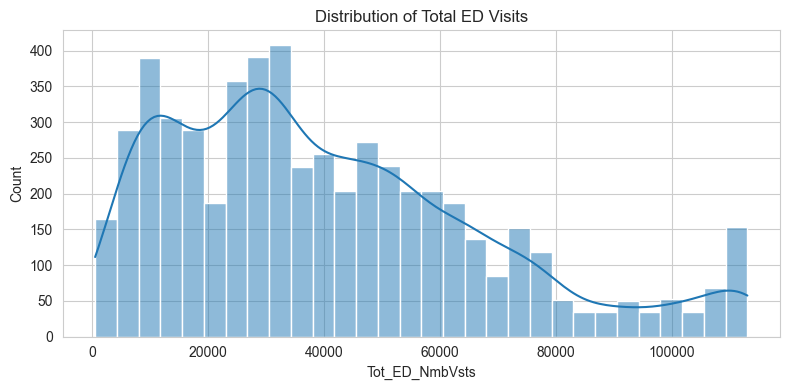

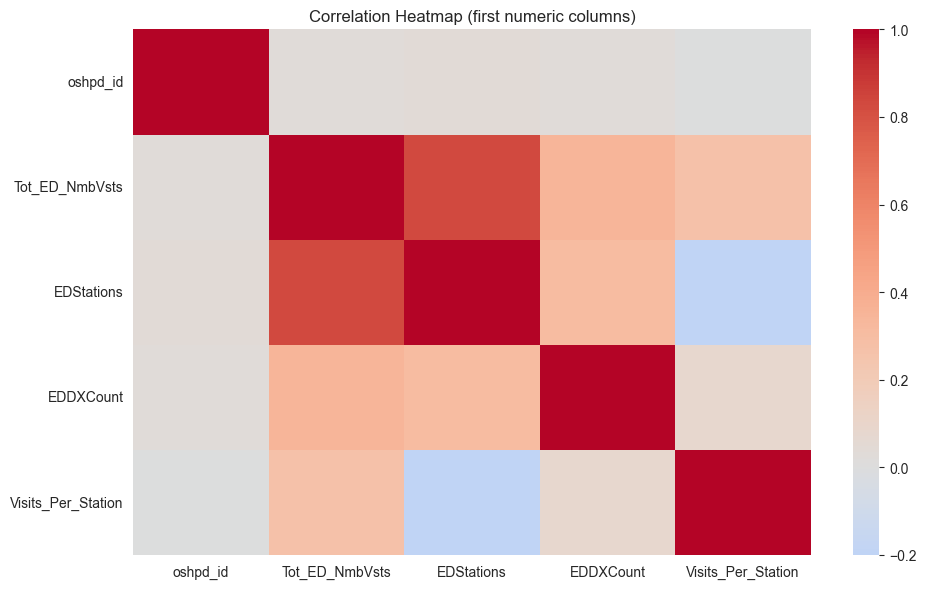

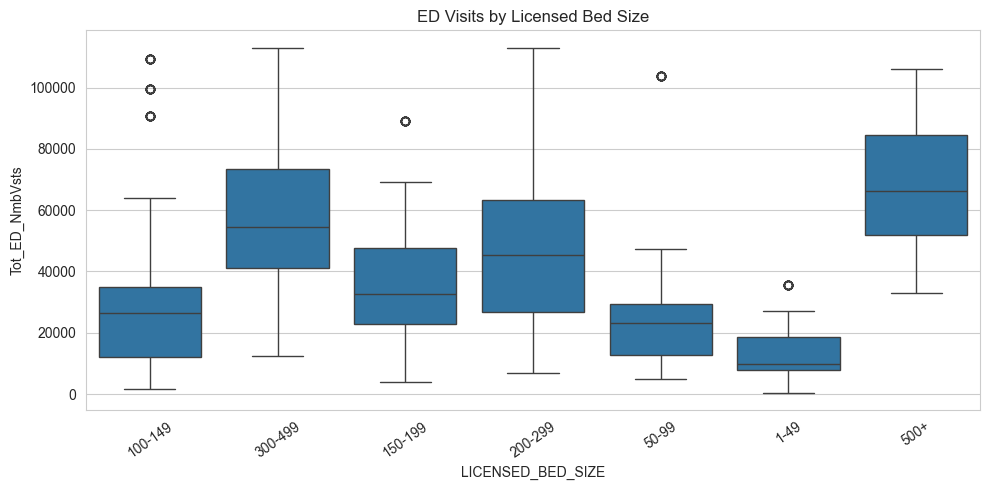

Created cleaned dataframe: df_clean


In [10]:
from IPython.display import display

# 1) Work on a copy so original df remains available
if 'df' not in globals():
    raise ValueError("DataFrame 'df_cleaned' not found. Please run the data-loading cell first.")

df_clean = df_cleaned.copy()

df_clean.columns = [str(c).strip() for c in df_clean.columns]


dups_before = int(df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates().reset_index(drop=True)


for col in df_clean.select_dtypes(include=['object']).columns:
    parsed = pd.to_numeric(df_clean[col], errors='coerce')
    parse_ratio = parsed.notna().mean()
    if parse_ratio >= 0.8:
        df_clean[col] = parsed

missing_before = df_clean.isna().sum()
num_cols = df_clean.select_dtypes(include=['number']).columns
cat_cols = df_clean.select_dtypes(exclude=['number']).columns

for col in num_cols:
    if df_clean[col].isna().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in cat_cols:
    if df_clean[col].isna().any():
        modes = df_clean[col].mode(dropna=True)
        fill_value = modes.iloc[0] if not modes.empty else 'Unknown'
        df_clean[col] = df_clean[col].fillna(fill_value)


for col in num_cols:
    if df_clean[col].nunique(dropna=True) > 10:
        q1 = df_clean[col].quantile(0.25)
        q3 = df_clean[col].quantile(0.75)
        iqr = q3 - q1
        if pd.notna(iqr) and iqr > 0:
            low = q1 - 1.5 * iqr
            high = q3 + 1.5 * iqr
            df_clean[col] = df_clean[col].clip(low, high)

if {'Tot_ED_NmbVsts', 'EDStations'}.issubset(df_clean.columns):
    stations = df_clean['EDStations'].replace(0, np.nan)
    df_clean['Visits_Per_Station'] = df_clean['Tot_ED_NmbVsts'] / stations
    df_clean['Visits_Per_Station'] = df_clean['Visits_Per_Station'].replace([np.inf, -np.inf], np.nan)
    df_clean['Visits_Per_Station'] = df_clean['Visits_Per_Station'].fillna(df_clean['Visits_Per_Station'].median())

missing_after = df_clean.isna().sum()

print('=== CLEANING SUMMARY ===')
print(f'Original shape: {df.shape} | Cleaned shape: {df_clean.shape}')
print(f'Duplicates removed: {dups_before}')
print(f'Total missing before: {int(missing_before.sum())}')
print(f'Total missing after : {int(missing_after.sum())}')

print('\n=== QUICK EDA ===')
print('Data types:')
display(df_clean.dtypes.to_frame('dtype').T)

print('Top missing counts after cleaning (should be mostly zeros):')
display(missing_after.sort_values(ascending=False).head(10).to_frame('missing_count'))

print('Numeric summary:')
if len(num_cols) > 0:
    display(df_clean[num_cols].describe().T)
else:
    print('No numeric columns found.')

print('Categorical summary:')
if len(cat_cols) > 0:
    display(df_clean[cat_cols].describe().T)
else:
    print('No categorical columns found.')

sns.set_style('whitegrid')

if 'Tot_ED_NmbVsts' in df_clean.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_clean['Tot_ED_NmbVsts'], kde=True, bins=30)
    plt.title('Distribution of Total ED Visits')
    plt.tight_layout()
    plt.show()

num_cols_now = df_clean.select_dtypes(include=['number']).columns
if len(num_cols_now) >= 2:
    corr = df_clean[num_cols_now].corr(numeric_only=True)
    n = min(12, corr.shape[0])
    corr_small = corr.iloc[:n, :n]
    plt.figure(figsize=(10, 6))
    sns.heatmap(corr_small, cmap='coolwarm', annot=False, center=0)
    plt.title('Correlation Heatmap (first numeric columns)')
    plt.tight_layout()
    plt.show()

if {'LICENSED_BED_SIZE', 'Tot_ED_NmbVsts'}.issubset(df_clean.columns):
    top_levels = df_clean['LICENSED_BED_SIZE'].astype(str).value_counts().head(8).index
    subset = df_clean[df_clean['LICENSED_BED_SIZE'].astype(str).isin(top_levels)]
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=subset, x='LICENSED_BED_SIZE', y='Tot_ED_NmbVsts')
    plt.title('ED Visits by Licensed Bed Size')
    plt.xticks(rotation=35)
    plt.tight_layout()
    plt.show()

print('Created cleaned dataframe: df_clean')

In [11]:
df_clean.count()

oshpd_id                    5583
LICENSED_BED_SIZE           5583
HospitalOwnership           5583
UrbanRuralDesi              5583
TEACHINGDesignation         5583
Category                    5583
Tot_ED_NmbVsts              5583
EDStations                  5583
EDDXCount                   5583
PrimaryCareShortageArea     5583
MentalHealthShortageArea    5583
Visits_Per_Station          5583
dtype: int64

<Axes: xlabel='UrbanRuralDesi', ylabel='Tot_ED_NmbVsts'>

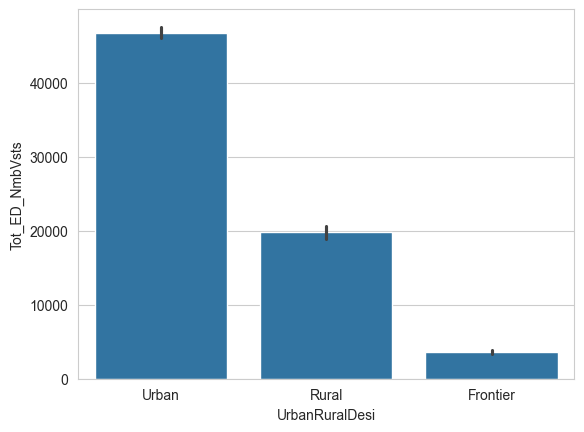

In [12]:
sns.barplot(x='UrbanRuralDesi', y='Tot_ED_NmbVsts', data=df_clean)


<Axes: xlabel='PrimaryCareShortageArea', ylabel='Count'>

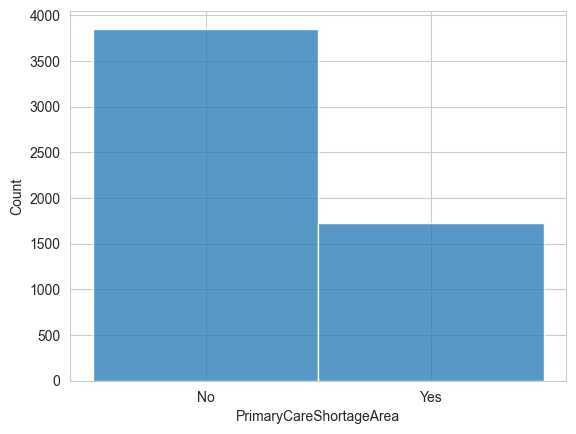

In [13]:
sns.histplot(x='PrimaryCareShortageArea', data=df_clean)


<Axes: xlabel='MentalHealthShortageArea', ylabel='Count'>

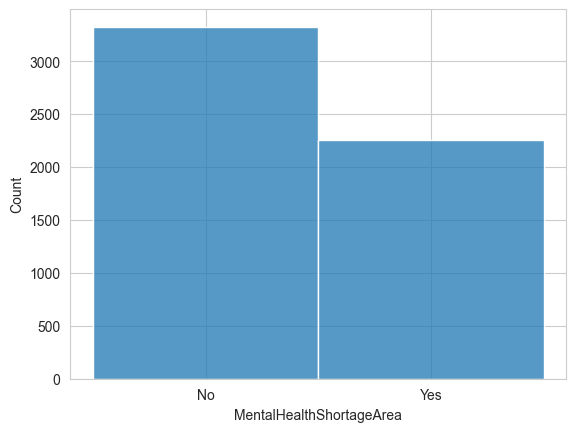

In [14]:
sns.histplot(x='MentalHealthShortageArea', data=df_clean)

<Axes: xlabel='HospitalOwnership', ylabel='Tot_ED_NmbVsts'>

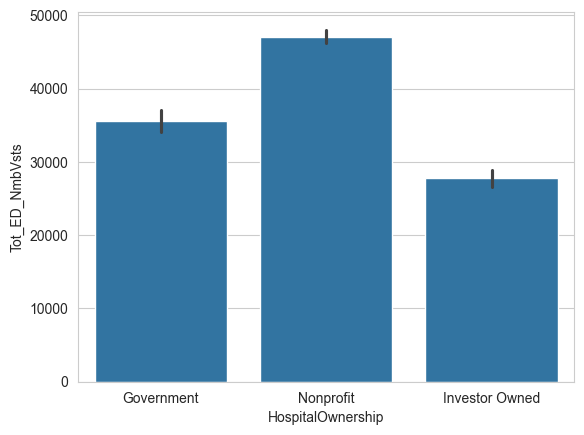

In [15]:
sns.barplot(x='HospitalOwnership', y='Tot_ED_NmbVsts', data=df_clean)


<Axes: xlabel='LICENSED_BED_SIZE', ylabel='Tot_ED_NmbVsts'>

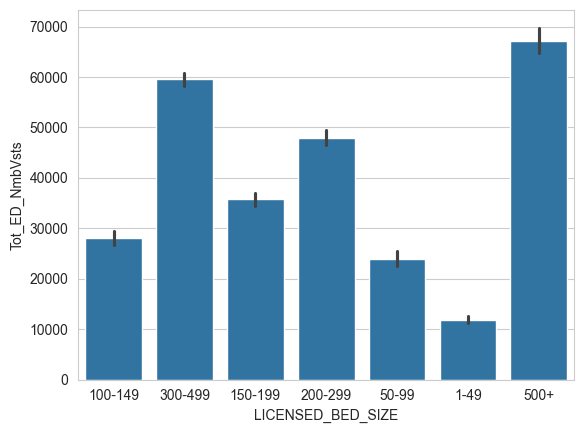

In [16]:
sns.barplot(x='LICENSED_BED_SIZE', y='Tot_ED_NmbVsts', data=df_clean)


<Axes: xlabel='Tot_ED_NmbVsts', ylabel='Count'>

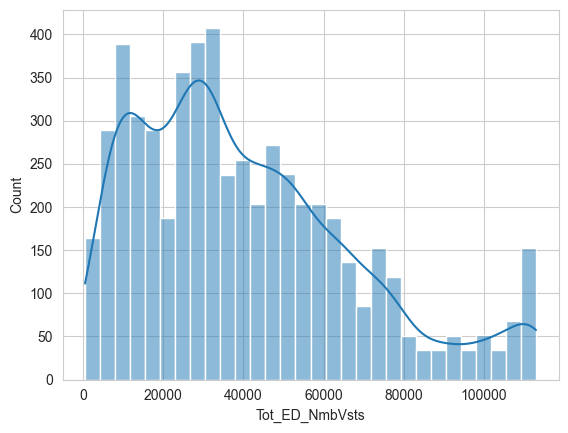

In [20]:
sns.histplot(df_clean['Tot_ED_NmbVsts'], bins=30, kde=True)

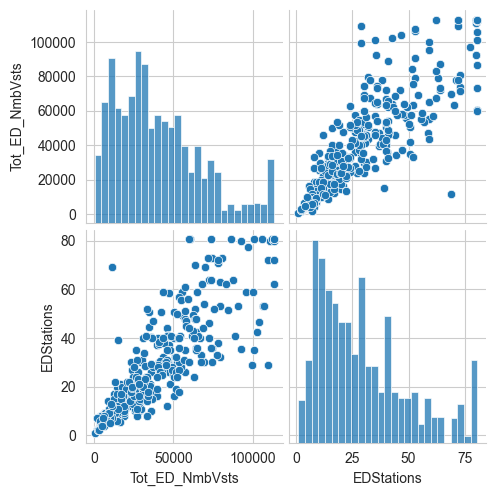

In [21]:
sns.pairplot(df_clean[['Tot_ED_NmbVsts', 'EDStations', 'LICENSED_BED_SIZE']])

<Axes: xlabel='LICENSED_BED_SIZE', ylabel='Tot_ED_NmbVsts'>

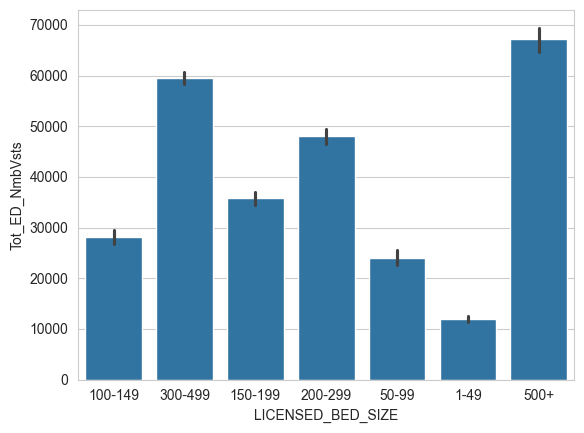

In [22]:
sns.barplot(x='LICENSED_BED_SIZE', y='Tot_ED_NmbVsts', data=df_clean)

In [24]:
df_clean['TEACHINGDesignation'].fillna('Non-Teaching', inplace=True)
df_clean = df_clean[(df_clean['Tot_ED_NmbVsts'] > 0) & (df_clean['EDStations'] > 0)]

C:\Users\rajasg1\AppData\Local\Temp\ipykernel_20744\67418554.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['TEACHINGDesignation'].fillna('Non-Teaching', inplace=True)


In [25]:
bed_mapping = {'1-49': 1, '50-99': 2, '100-149': 3, '150-199': 4, '200-299': 5, '300-499': 6, '500+': 7}
df_clean['Bed_Size_Encoded'] = df_clean['LICENSED_BED_SIZE'].map(bed_mapping)

In [27]:
df_clean.drop(columns=['LICENSED_BED_SIZE'], inplace=True)

In [28]:
df_clean.head()

,oshpd_id,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,PrimaryCareShortageArea,MentalHealthShortageArea,Visits_Per_Station,Bed_Size_Encoded
0,106010735,Government,Urban,Non-Teaching,Active COVID-19,13261.000000,12.0,349.000000,No,No,1105.083333,3
1,106010739,Nonprofit,Urban,Non-Teaching,Active COVID-19,29420.666667,22.0,826.666667,No,No,1337.303030,6
2,106010776,Nonprofit,Urban,Teaching,Active COVID-19,30782.500000,40.0,1152.500000,No,No,769.562500,4
3,106010846,Government,Urban,Non-Teaching,Active COVID-19,65082.000000,59.0,1765.000000,No,No,1103.084746,5
4,106010937,Nonprofit,Urban,Non-Teaching,Active COVID-19,29479.000000,30.0,925.333333,No,No,982.633333,6


In [29]:
categorical_cols = ['HospitalOwnership', 'UrbanRuralDesi', 'TEACHINGDesignation','Category', 'PrimaryCareShortageArea','MentalHealthShortageArea']
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

In [30]:
features = ['Bed_Size_Encoded', 'EDStations'] + [col for col in df_encoded.columns if 'HospitalOwnership_' in col or 'UrbanRuralDesi_' in col]
df_model = df_encoded.dropna(subset=features + ['Visits_Per_Station'])


In [31]:
X = df_model[features]
y = df_model['Visits_Per_Station']


In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [33]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [34]:

print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Random Forest RMSE: 217.87833490643308
Random Forest R2: 0.8612183577041872


1.	Assess capacity strain and overcrowding by identifying the overburdened hospitals based on the encounters per treatment station by identifying drivers which cohorts contribute most to high burden and try to mitigate the same using under burdened departments in the hospital.

In [38]:
df_clean.head()

,oshpd_id,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,PrimaryCareShortageArea,MentalHealthShortageArea,Visits_Per_Station,Bed_Size_Encoded,Burden_Status
0,106010735,Government,Urban,Non-Teaching,Active COVID-19,13261.000000,12.0,349.000000,No,No,1105.082412,3,Normal
1,106010739,Nonprofit,Urban,Non-Teaching,Active COVID-19,29420.666667,22.0,826.666667,No,No,1337.302422,6,Normal
2,106010776,Nonprofit,Urban,Teaching,Active COVID-19,30782.500000,40.0,1152.500000,No,No,769.562308,4,Under-Burdened
3,106010846,Government,Urban,Non-Teaching,Active COVID-19,65082.000000,59.0,1765.000000,No,No,1103.084559,5,Normal
4,106010937,Nonprofit,Urban,Non-Teaching,Active COVID-19,29479.000000,30.0,925.333333,No,No,982.633006,6,Under-Burdened


In [40]:
df_clean['Visits_Per_Station'] = df_clean['Tot_ED_NmbVsts'] / (df_clean['EDStations'] + 1e-5)
df_clean = df_clean.replace([np.inf, -np.inf], np.nan).dropna(subset=['Visits_Per_Station'])

high_burden_threshold = df_clean['Visits_Per_Station'].quantile(0.75)
low_burden_threshold = df_clean['Visits_Per_Station'].quantile(0.25)

df_clean['Burden_Status'] = pd.cut(
    df_clean['Visits_Per_Station'], 
    bins=[-np.inf, low_burden_threshold, high_burden_threshold, np.inf], 
    labels=['Under-Burdened', 'Normal', 'Overburdened']
)

print("\n--- Capacity Strain Overview ---")
print(df_clean['Burden_Status'].value_counts())




print("\n--- Training Regression Models ---")
features = ['UrbanRuralDesi', 'HospitalOwnership', 'TEACHINGDesignation', 'EDStations','PrimaryCareShortageArea','MentalHealthShortageArea']
X = df_clean[features]
y = df_clean['Visits_Per_Station']

categorical_cols = ['UrbanRuralDesi', 'HospitalOwnership', 'TEACHINGDesignation','PrimaryCareShortageArea','MentalHealthShortageArea']
numerical_cols = ['EDStations', 'Bed_Size_Encoded']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


--- Capacity Strain Overview ---
Burden_Status
Normal            2786
Under-Burdened    1403
Overburdened      1394
Name: count, dtype: int64

--- Training Regression Models ---


In [41]:
numerical_cols = ['EDStations']
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

models = {
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost Regressor': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    'Support Vector Regression': SVR(kernel='rbf', C=100, gamma='scale')
}

results = {}
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results[name] = {'MAE': mae, 'RMSE': rmse}

results_df = pd.DataFrame(results).T
print("\n--- Model Evaluation Results ---")
print(results_df.round(2))


--- Model Evaluation Results ---
                              MAE    RMSE
Random Forest Regressor    113.49  230.22
XGBoost Regressor          156.09  245.59
Support Vector Regression  347.42  502.13


2.	Identifying the hospitals based on the clustering specifying the specialization catered, presence of the primary health care and mental health care, bed sizes, hospital ownership.

In [43]:
categorical_cols = ['HospitalOwnership', 'UrbanRuralDesi', 'TEACHINGDesignation','PrimaryCareShortageArea','MentalHealthShortageArea']
numerical_cols = ['EDStations','Bed_Size_Encoded','Visits_Per_Station','Tot_ED_NmbVsts']

df_clean_updated = df_clean.dropna(subset=categorical_cols + numerical_cols).copy()
scaler = StandardScaler()
df_clean_updated['EDStations_Scaled'] = scaler.fit_transform(df_clean_updated[['EDStations']])
kproto_data = df_clean_updated[categorical_cols + ['EDStations_Scaled']]

categorical_indices = [kproto_data.columns.get_loc(col) for col in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])
X_encoded = preprocessor.fit_transform(df_clean)


--- Running Elbow Method for K-Prototypes ---
K=2 Cost: 5743.80
K=3 Cost: 4203.06
K=4 Cost: 3388.05
K=5 Cost: 2980.30
K=6 Cost: 2775.83
K=7 Cost: 2488.85


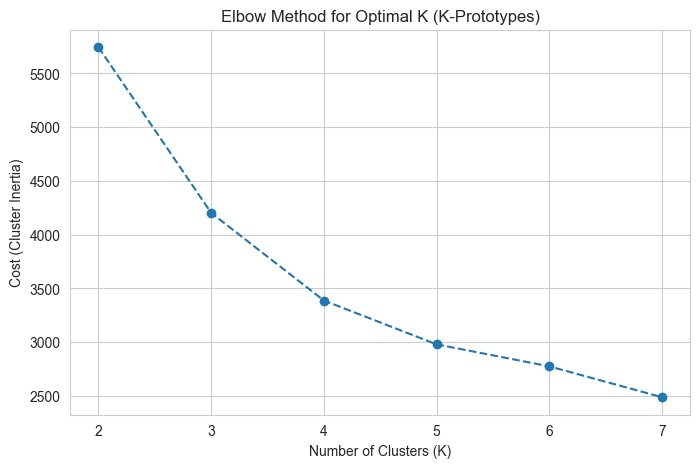

In [44]:
print("\n--- Running Elbow Method for K-Prototypes ---")
costs = []
K_range = range(2, 8)

for k in K_range:
    # Initialize K-Prototypes
    kproto = KPrototypes(n_clusters=k, init='Cao', random_state=42, n_jobs=-1)
    kproto.fit(kproto_data, categorical=categorical_indices)
    costs.append(kproto.cost_)
    print(f"K={k} Cost: {kproto.cost_:.2f}")

# Plotting the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, costs, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K (K-Prototypes)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Cost (Cluster Inertia)')
plt.grid(True)
plt.show()

In [45]:
optimal_k = 5
print(f"\nTraining Final K-Prototypes Model with K={optimal_k}...")
final_kproto = KPrototypes(n_clusters=optimal_k, init='Cao', random_state=42, n_jobs=-1)
kproto_clusters = final_kproto.fit_predict(kproto_data, categorical=categorical_indices)
df_clean['KProto_Cluster'] = kproto_clusters

dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_clusters = dbscan.fit_predict(X_encoded)
df_clean['DBSCAN_Cluster'] = dbscan_clusters

n_noise = list(dbscan_clusters).count(-1)
print(f"Estimated number of DBSCAN clusters: {len(set(dbscan_clusters)) - (1 if -1 in dbscan_clusters else 0)}")
print(f"Estimated number of noise points: {n_noise}")


def evaluate_clustering(model_name, labels, data):
    if len(set(labels)) > 1:
        sil_score = silhouette_score(data, labels)
        calinski_score = calinski_harabasz_score(data, labels)
        print(f"** {model_name} **")
        print(f"  Silhouette Score: {sil_score:.4f} (Closer to 1 is better, < 0 means overlapping)")
        print(f"  Calinski-Harabasz Index: {calinski_score:.4f} (Higher means denser, more separated clusters)")
    else:
        print(f"** {model_name} **")
        print("  Could not calculate metrics: Only one valid cluster found (or all noise).")

evaluate_clustering("K-Prototypes", df_clean['KProto_Cluster'], X_encoded)
evaluate_clustering("DBSCAN", df_clean['DBSCAN_Cluster'], X_encoded)


for cluster_num in range(optimal_k):
    cluster_data = df_clean[df_clean['KProto_Cluster'] == cluster_num]
    print(f"\nCluster {cluster_num} (Size: {len(cluster_data)} hospitals):")
    for col in categorical_cols:
        top_category = cluster_data[col].mode()[0]
        print(f"  - Dominant {col}: {top_category}")
    avg_stations = cluster_data['EDStations'].mean()
    print(f"  - Average ED Stations: {avg_stations:.1f}")


Training Final K-Prototypes Model with K=5...
Estimated number of DBSCAN clusters: 12
Estimated number of noise points: 0
** K-Prototypes **
  Silhouette Score: 0.1713 (Closer to 1 is better, < 0 means overlapping)
  Calinski-Harabasz Index: 1413.5361 (Higher means denser, more separated clusters)
** DBSCAN **
  Silhouette Score: -0.0742 (Closer to 1 is better, < 0 means overlapping)
  Calinski-Harabasz Index: 58.6201 (Higher means denser, more separated clusters)

Cluster 0 (Size: 661 hospitals):
  - Dominant HospitalOwnership: Nonprofit
  - Dominant UrbanRuralDesi: Urban
  - Dominant TEACHINGDesignation: Non-Teaching
  - Dominant PrimaryCareShortageArea: No
  - Dominant MentalHealthShortageArea: No
  - Average ED Stations: 70.5

Cluster 1 (Size: 1169 hospitals):
  - Dominant HospitalOwnership: Nonprofit
  - Dominant UrbanRuralDesi: Rural
  - Dominant TEACHINGDesignation: Non-Teaching
  - Dominant PrimaryCareShortageArea: Yes
  - Dominant MentalHealthShortageArea: Yes
  - Average ED 

3.	Predicting the health care shortage i.e. Primary care shortage and Mental Health care shortage based on the visits per station, country name, category, hospital ownership and urban- rural criteria. We can use Binary classification to predict whether there is shortage or not.

In [46]:
df_clean.head()

,oshpd_id,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,PrimaryCareShortageArea,MentalHealthShortageArea,Visits_Per_Station,Bed_Size_Encoded,Burden_Status,KProto_Cluster,DBSCAN_Cluster
0,106010735,Government,Urban,Non-Teaching,Active COVID-19,13261.000000,12.0,349.000000,No,No,1105.082412,3,Normal,4,0
1,106010739,Nonprofit,Urban,Non-Teaching,Active COVID-19,29420.666667,22.0,826.666667,No,No,1337.302422,6,Normal,2,0
2,106010776,Nonprofit,Urban,Teaching,Active COVID-19,30782.500000,40.0,1152.500000,No,No,769.562308,4,Under-Burdened,3,0
3,106010846,Government,Urban,Non-Teaching,Active COVID-19,65082.000000,59.0,1765.000000,No,No,1103.084559,5,Normal,0,0
4,106010937,Nonprofit,Urban,Non-Teaching,Active COVID-19,29479.000000,30.0,925.333333,No,No,982.633006,6,Under-Burdened,2,0


In [51]:

from sklearn.preprocessing import LabelEncoder


df_clean['Visits_Per_Station'] = df_clean['Tot_ED_NmbVsts'] / (df_clean['EDStations'] + 1e-5)

features = ['HospitalOwnership', 'UrbanRuralDesi', 'TEACHINGDesignation','EDStations','Bed_Size_Encoded','Visits_Per_Station','Tot_ED_NmbVsts','MentalHealthShortageArea']
target_col = 'PrimaryCareShortageArea'

df_clean = df_clean.dropna(subset=features + [target_col])

le = LabelEncoder()
y = le.fit_transform(df_clean[target_col])
print(f"Target Encoding mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

X = df_clean[features]

categorical_cols = ['HospitalOwnership', 'UrbanRuralDesi', 'TEACHINGDesignation','MentalHealthShortageArea']
numerical_cols = ['EDStations','Bed_Size_Encoded','Visits_Per_Station','Tot_ED_NmbVsts']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



Target Encoding mapping: {'No': np.int64(0), 'Yes': np.int64(1)}


In [52]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, confusion_matrix, roc_auc_score


models = {
    'XGBoost Classifier': XGBClassifier(
        n_estimators=100, 
        learning_rate=0.1, 
        max_depth=5, 
        use_label_encoder=False, 
        eval_metric='logloss',
        random_state=42
    ),
    'LightGBM Classifier': LGBMClassifier(
        n_estimators=100, 
        learning_rate=0.1, 
        max_depth=5, 
        random_state=42,
        verbose=-1 
    )
}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1] # Probabilities for ROC AUC
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    print(f"Accuracy:  {acc:.4f}")
    print(f"ROC AUC:   {roc_auc:.4f}\n")
    
    print("Classification Report:")
    # Pass target names for better readability in the report
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(pd.DataFrame(cm, index=[f'Actual {c}' for c in le.classes_], columns=[f'Predicted {c}' for c in le.classes_]))


print("\n--- Feature Importance (LightGBM) ---")
lgbm_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', models['LightGBM Classifier'])])
lgbm_pipeline.fit(X_train, y_train)

cat_feature_names = lgbm_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + list(cat_feature_names)

importances = lgbm_pipeline.named_steps['classifier'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10).to_string(index=False))

c:\Users\rajasg1\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:42:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy:  1.0000
ROC AUC:   1.0000

Classification Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00       771
         Yes       1.00      1.00      1.00       346

    accuracy                           1.00      1117
   macro avg       1.00      1.00      1.00      1117
weighted avg       1.00      1.00      1.00      1117

Confusion Matrix:
            Predicted No  Predicted Yes
Actual No            771              0
Actual Yes             0            346
Accuracy:  0.9991
ROC AUC:   1.0000

Classification Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00       771
         Yes       1.00      1.00      1.00       346

    accuracy                           1.00      1117
   macro avg       1.00      1.00      1.00      1117
weighted avg       1.00      1.00      1.00      1117

Confusion Matrix:
            Predicted No  Predicted Yes
Actual No            770      

c:\Users\rajasg1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\rajasg1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [53]:
df_clean['Visits_Per_Station'] = df_clean['Tot_ED_NmbVsts'] / (df_clean['EDStations'] + 1e-5)

features = ['HospitalOwnership', 'UrbanRuralDesi', 'TEACHINGDesignation','EDStations','Bed_Size_Encoded','Visits_Per_Station','Tot_ED_NmbVsts','PrimaryCareShortageArea']
target_col = 'MentalHealthShortageArea'

df_clean = df_clean.dropna(subset=features + [target_col])

le = LabelEncoder()
y = le.fit_transform(df_clean[target_col])
print(f"Target Encoding mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

X = df_clean[features]

categorical_cols = ['HospitalOwnership', 'UrbanRuralDesi', 'TEACHINGDesignation','PrimaryCareShortageArea']
numerical_cols = ['EDStations','Bed_Size_Encoded','Visits_Per_Station','Tot_ED_NmbVsts']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



Target Encoding mapping: {'No': np.int64(0), 'Yes': np.int64(1)}


In [54]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, confusion_matrix, roc_auc_score


models = {
    'XGBoost Classifier': XGBClassifier(
        n_estimators=100, 
        learning_rate=0.1, 
        max_depth=5, 
        use_label_encoder=False, 
        eval_metric='logloss',
        random_state=42
    ),
    'LightGBM Classifier': LGBMClassifier(
        n_estimators=100, 
        learning_rate=0.1, 
        max_depth=5, 
        random_state=42,
        verbose=-1 
    )
}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1] # Probabilities for ROC AUC
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    print(f"Accuracy:  {acc:.4f}")
    print(f"ROC AUC:   {roc_auc:.4f}\n")
    
    print("Classification Report:")
    # Pass target names for better readability in the report
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(pd.DataFrame(cm, index=[f'Actual {c}' for c in le.classes_], columns=[f'Predicted {c}' for c in le.classes_]))


print("\n--- Feature Importance (LightGBM) ---")
lgbm_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', models['LightGBM Classifier'])])
lgbm_pipeline.fit(X_train, y_train)

cat_feature_names = lgbm_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + list(cat_feature_names)

importances = lgbm_pipeline.named_steps['classifier'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10).to_string(index=False))

c:\Users\rajasg1\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:44:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\rajasg1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\rajasg1\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy:  1.0000
ROC AUC:   1.0000

Classification Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00       665
         Yes       1.00      1.00      1.00       452

    accuracy                           1.00      1117
   macro avg       1.00      1.00      1.00      1117
weighted avg       1.00      1.00      1.00      1117

Confusion Matrix:
            Predicted No  Predicted Yes
Actual No            665              0
Actual Yes             0            452
Accuracy:  1.0000
ROC AUC:   1.0000

Classification Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00       665
         Yes       1.00      1.00      1.00       452

    accuracy                           1.00      1117
   macro avg       1.00      1.00      1.00      1117
weighted avg       1.00      1.00      1.00      1117

Confusion Matrix:
            Predicted No  Predicted Yes
Actual No            665      

4.	Predicting Patient diagnosis category profiling i.e. discovering the hidden patterns about types of hospitals attract patients with specific illness based on the categories, teaching designation, hospital ownership, bed sizes, number of visits and visits per station.

In [62]:
df_clean.head()

,oshpd_id,HospitalOwnership,UrbanRuralDesi,TEACHINGDesignation,Category,Tot_ED_NmbVsts,EDStations,EDDXCount,PrimaryCareShortageArea,MentalHealthShortageArea,Visits_Per_Station,Bed_Size_Encoded,Burden_Status,KProto_Cluster,DBSCAN_Cluster,Visits_Volume_Bin,Capacity_Strain_Bin
0,106010735,Government,Urban,Non-Teaching,Active COVID-19,13261.000000,12.0,349.000000,No,No,1105.082412,3,Normal,4,0,Low Volume,Low Strain
1,106010739,Nonprofit,Urban,Non-Teaching,Active COVID-19,29420.666667,22.0,826.666667,No,No,1337.302422,6,Normal,2,0,Medium Volume,Medium Strain
2,106010776,Nonprofit,Urban,Teaching,Active COVID-19,30782.500000,40.0,1152.500000,No,No,769.562308,4,Under-Burdened,3,0,Medium Volume,Low Strain
3,106010846,Government,Urban,Non-Teaching,Active COVID-19,65082.000000,59.0,1765.000000,No,No,1103.084559,5,Normal,0,0,High Volume,Low Strain
4,106010937,Nonprofit,Urban,Non-Teaching,Active COVID-19,29479.000000,30.0,925.333333,No,No,982.633006,6,Under-Burdened,2,0,Medium Volume,Low Strain


In [68]:
df_clean['Visits_Per_Station'] = df_clean['Tot_ED_NmbVsts'] / (df_clean['EDStations'] + 1e-5)


df_clean['Visits_Volume_Bin'] = pd.qcut(df_clean['Tot_ED_NmbVsts'], q=3, labels=['Low Volume', 'Medium Volume', 'High Volume'])
df_clean['Capacity_Strain_Bin'] = pd.qcut(df_clean['Visits_Per_Station'], q=3, labels=['Low Strain', 'Medium Strain', 'High Strain'])

categorical_features = [
    'Category', 
    'TEACHINGDesignation', 
    'HospitalOwnership', 
    'UrbanRuralDesi', 
    'PrimaryCareShortageArea', 
    'MentalHealthShortageArea',
    'EDStations',
    'Visits_Volume_Bin', 
    'Capacity_Strain_Bin'
]

df_mining = df_clean[categorical_features].dropna()

transactions = []
for index, row in df_mining.iterrows():
    transaction = [f"{col}={row[col]}" for col in df_mining.columns]
    transactions.append(transaction)

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_fp = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = fpgrowth(df_fp, min_support=0.05, use_colnames=True)

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.1)

def is_diagnosis_consequent(consequents):
    return any('Diagnosis_Category' in item for item in consequents)

diagnosis_rules = rules[rules['consequents'].apply(is_diagnosis_consequent)].copy()


diagnosis_rules = diagnosis_rules.sort_values(by=['confidence', 'lift'], ascending=[False, False])

print(f"Found {len(diagnosis_rules)} meaningful rules predicting patient diagnosis profiles.\n")
print("Top 5 Hidden Patterns (Rules):")
for idx, row in diagnosis_rules.head(5).iterrows():
    antecedents = ", ".join(list(row['antecedents']))
    consequents = ", ".join(list(row['consequents']))
    print(f"Rule: IF [{antecedents}] ---> THEN LIKELY [{consequents}]")
    print(f"      (Confidence: {row['confidence']:.2f}, Lift: {row['lift']:.2f})")

Found 0 meaningful rules predicting patient diagnosis profiles.

Top 5 Hidden Patterns (Rules):


In [69]:
df_mining.head()

,Category,TEACHINGDesignation,HospitalOwnership,UrbanRuralDesi,PrimaryCareShortageArea,MentalHealthShortageArea,EDStations,Visits_Volume_Bin,Capacity_Strain_Bin
0,Active COVID-19,Non-Teaching,Government,Urban,No,No,12.0,Low Volume,Low Strain
1,Active COVID-19,Non-Teaching,Nonprofit,Urban,No,No,22.0,Medium Volume,Medium Strain
2,Active COVID-19,Teaching,Nonprofit,Urban,No,No,40.0,Medium Volume,Low Strain
3,Active COVID-19,Non-Teaching,Government,Urban,No,No,59.0,High Volume,Low Strain
4,Active COVID-19,Non-Teaching,Nonprofit,Urban,No,No,30.0,Medium Volume,Low Strain


In [70]:
print(" K-MODES: PATIENT-HOSPITAL PROFILING CLUSTERS")
km = KModes(n_clusters=4, init='Cao', n_init=6, verbose=0, random_state=42)

clusters = km.fit_predict(df_mining)
df_mining['Cluster'] = clusters

cluster_centroids = pd.DataFrame(km.cluster_centroids_, columns=categorical_features)

for i, row in cluster_centroids.iterrows():
    cluster_size = len(df_mining[df_mining['Cluster'] == i])
    print(f"\n--- Cluster {i} Profile (Contains {cluster_size} hospitals) ---")
    print(f"  * Teaching Status:     {row['TEACHINGDesignation']}")
    print(f"  * Ownership Type:      {row['HospitalOwnership']}")
    print(f"  * Visit Volume:        {row['Visits_Volume_Bin']}")
    print(f"  * Capacity Strain:     {row['Capacity_Strain_Bin']}")

 K-MODES: PATIENT-HOSPITAL PROFILING CLUSTERS

--- Cluster 0 Profile (Contains 3212 hospitals) ---
  * Teaching Status:     Non-Teaching
  * Ownership Type:      Nonprofit
  * Visit Volume:        Low Volume
  * Capacity Strain:     Medium Strain

--- Cluster 1 Profile (Contains 1130 hospitals) ---
  * Teaching Status:     Non-Teaching
  * Ownership Type:      Investor Owned
  * Visit Volume:        Medium Volume
  * Capacity Strain:     High Strain

--- Cluster 2 Profile (Contains 651 hospitals) ---
  * Teaching Status:     Non-Teaching
  * Ownership Type:      Government
  * Visit Volume:        High Volume
  * Capacity Strain:     Low Strain

--- Cluster 3 Profile (Contains 590 hospitals) ---
  * Teaching Status:     Non-Teaching
  * Ownership Type:      Government
  * Visit Volume:        Medium Volume
  * Capacity Strain:     High Strain
